# 01 — Foundations & the Leakage Trap

> **All About Cross-Validation**, Notebook 1 of 4.
> *How do I honestly measure how good my model is — and the one mistake that quietly ruins that measurement?*

Every model looks brilliant on the data it was trained on. The entire job of **validation**
is to estimate how a model will do on data it has **never seen**. Get this wrong and every
number downstream — your accuracy, your leaderboard rank, your "the model is ready" — is a
comfortable lie.

This notebook builds the foundation the other three stand on:

1. **Why training accuracy lies** — the overfitting trap in one experiment.
2. **Why a single train/test split is a lottery** — and how cross-validation fixes it.
3. **The Leakage Trap** — the single most common way real practitioners fool themselves,
   demonstrated by manufacturing **82% accuracy out of pure random noise**.
4. **Choosing K** — the bias / variance / runtime trade-off behind picking the number of folds.

### The series
| # | Notebook | Question it answers |
|---|----------|---------------------|
| **01** | **Foundations & the Leakage Trap** | *How do I measure honestly?* |
| 02 | The K-Fold Family | *Which splitting scheme fits my data?* |
| 03 | Grouped & Time-Aware CV | *What if rows aren't independent (groups, time)?* |
| 04 | Model Selection with CV | *How do I tune without cheating? (nested CV)* |

### The dataset — German Credit
1,000 loan applicants, each labelled **good** or **bad** credit risk. We predict the
minority, costly class: `bad_credit = 1` (30% of rows). It is **deliberately small** —
cross-validation matters *most* when data is scarce, because you cannot afford to waste
any of it on a single frozen test set.

In [1]:
import warnings; warnings.filterwarnings("ignore")
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
%matplotlib inline

sns.set_theme(style="whitegrid", context="talk")
plt.rcParams["figure.figsize"] = (10, 5)
RANDOM_STATE = 42

from cv_datasets import load_credit, feature_types
X, y = load_credit()
num_cols, cat_cols = feature_types(X)

print(f"X: {X.shape[0]} applicants x {X.shape[1]} features "
      f"({len(num_cols)} numeric, {len(cat_cols)} categorical)")
print(f"Target 'bad_credit': {y.mean():.0%} positive  "
      f"({(y==1).sum()} bad / {(y==0).sum()} good)")
X.head(3)

X: 1000 applicants x 20 features (7 numeric, 13 categorical)
Target 'bad_credit': 30% positive  (300 bad / 700 good)


,checking_status,duration,credit_history,purpose,credit_amount,savings_status,employment,installment_commitment,personal_status,other_parties,residence_since,property_magnitude,age,other_payment_plans,housing,existing_credits,job,num_dependents,own_telephone,foreign_worker
0,<0,6,critical/other existing credit,radio/tv,1169,no known savings,>=7,4,male single,none,4,real estate,67,none,own,2,skilled,1,yes,yes
1,0<=X<200,48,existing paid,radio/tv,5951,<100,1<=X<4,2,female div/dep/mar,none,2,real estate,22,none,own,1,skilled,1,none,yes
2,no checking,12,critical/other existing credit,education,2096,<100,4<=X<7,2,male single,none,3,real estate,49,none,own,1,unskilled resident,2,none,yes


Notice the features are a mix of **numeric** (`duration`, `credit_amount`, `age`, …) and
**categorical** (`checking_status`, `purpose`, `housing`, …). They are left *raw* on
purpose. Turning categories into numbers and scaling the numeric columns is **preprocessing**,
and *when* you do that preprocessing relative to your split is exactly what Section 3 is about.

## Section 1 — Why training accuracy lies

Here is the trap every beginner falls into: train a model, score it on the **same rows**,
and celebrate. A flexible model can essentially **memorize** the training data, so that
score measures memory, not skill.

In [2]:
from sklearn.ensemble import RandomForestClassifier
from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.model_selection import train_test_split
from sklearn.metrics import roc_auc_score

# A reusable preprocessing block: scale numbers, one-hot encode categories.
def make_pipeline():
    pre = ColumnTransformer([
        ("num", StandardScaler(), num_cols),
        ("cat", OneHotEncoder(handle_unknown="ignore"), cat_cols),
    ])
    return Pipeline([("pre", pre),
                     ("rf", RandomForestClassifier(n_estimators=300,
                                                   random_state=RANDOM_STATE, n_jobs=-1))])

# Train on ALL the data, then score on that SAME data.
model = make_pipeline().fit(X, y)
train_auc = roc_auc_score(y, model.predict_proba(X)[:, 1])

# Now train on 70%, score on the held-out 30% it never saw.
X_tr, X_te, y_tr, y_te = train_test_split(X, y, test_size=0.30,
                                          stratify=y, random_state=RANDOM_STATE)
model_h = make_pipeline().fit(X_tr, y_tr)
holdout_auc = roc_auc_score(y_te, model_h.predict_proba(X_te)[:, 1])

print(f"AUC scored on the TRAINING data : {train_auc:.3f}   <- looks amazing")
print(f"AUC scored on UNSEEN holdout data: {holdout_auc:.3f}   <- the honest number")
print(f"\nThe {train_auc - holdout_auc:.3f} gap is pure self-deception (memorization).")

AUC scored on the TRAINING data : 1.000   <- looks amazing
AUC scored on UNSEEN holdout data: 0.797   <- the honest number

The 0.203 gap is pure self-deception (memorization).


### How to read this

- **Training AUC ≈ 1.0** does not mean the model is good — a Random Forest can carve the
  training rows into near-perfect memorized regions. It's measuring recall of what it already saw.
- **Holdout AUC ≈ 0.79** is the number that actually predicts future performance, because
  those 300 applicants played no part in fitting the model.
- **Rule #1:** *never* report a score computed on rows the model trained on. Always evaluate
  on held-out data.

## Section 2 — A single split is a lottery

The holdout above used `random_state=42`. But that was *one* arbitrary way to cut the data.
Change the seed and you get a different 30% test set — and a different score. On a small
dataset that luck-of-the-draw swing is large enough to change your conclusions.

Let's draw **200 different** 70/30 splits and look at the spread of holdout AUCs.

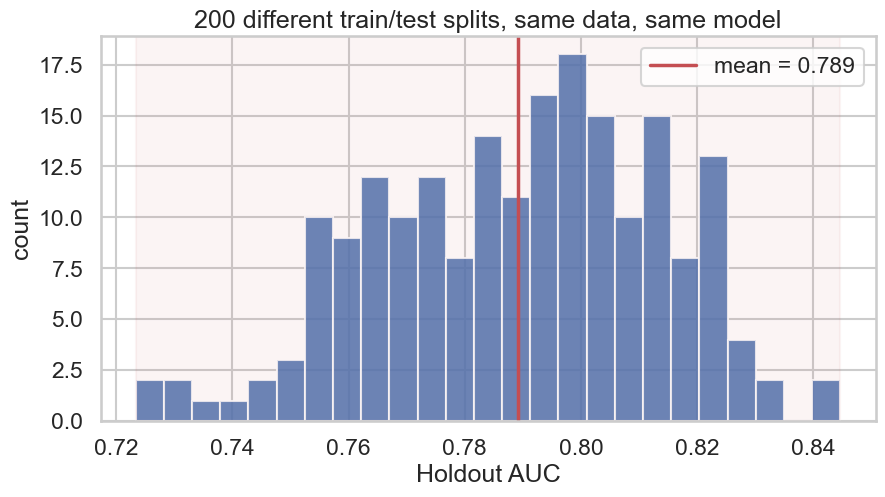

Best-case split : AUC 0.845
Worst-case split: AUC 0.723
Spread          : 0.121  <- your 'result' depends on luck


In [3]:
scores = []
for seed in range(200):
    Xtr, Xte, ytr, yte = train_test_split(X, y, test_size=0.30, stratify=y, random_state=seed)
    m = make_pipeline().fit(Xtr, ytr)
    scores.append(roc_auc_score(yte, m.predict_proba(Xte)[:, 1]))
scores = np.array(scores)

fig, ax = plt.subplots(figsize=(10, 5))
ax.hist(scores, bins=25, color="#4C72B0", alpha=0.85, edgecolor="white")
ax.axvline(scores.mean(), color="#C44E52", lw=2.5, label=f"mean = {scores.mean():.3f}")
ax.axvspan(scores.min(), scores.max(), color="#C44E52", alpha=0.06)
ax.set(title="200 different train/test splits, same data, same model",
       xlabel="Holdout AUC", ylabel="count")
ax.legend()
plt.show()

print(f"Best-case split : AUC {scores.max():.3f}")
print(f"Worst-case split: AUC {scores.min():.3f}")
print(f"Spread          : {scores.max() - scores.min():.3f}  <- your 'result' depends on luck")

### How to read this chart

- Each bar counts how many random splits produced an AUC in that range. The **red line** is
  the average; the shaded band is the full best-to-worst spread.
- The spread is often **0.10+** wide. If you had reported a single lucky split you'd claim
  ~0.83; an unlucky one says ~0.72 — different stories from identical data and code.
- **Cross-validation** kills this lottery: instead of trusting one split, it *rotates* the
  test set through every row and **averages**. The mean is stable; the spread across folds
  becomes information (a stability estimate) rather than noise you didn't know about.

## Section 3 — The Leakage Trap 🚨

This is the most important section in the whole series.

**Data leakage** is when information from the test rows sneaks into the training process.
The scores it produces look *great* and are *completely fake*. It almost always comes from
doing a "prep" step on the **whole dataset before splitting**:

- fitting a **scaler / imputer / encoder** on all rows,
- **feature selection** using the full target,
- **resampling** (SMOTE) before the split,
- **target/mean encoding** computed over everything.

Each of these lets the model peek at the test rows through the back door.

### The everyday leak (usually mild)
Scaling before splitting means the scaler's mean and standard deviation were computed using
test rows too. The effect is usually tiny — but the *habit* is the problem, because the same
habit becomes catastrophic below.

In [4]:
# The mechanism, made concrete: a scaler fit on ALL rows vs fit on TRAIN rows only.
full_mean  = X["credit_amount"].mean()
train_mean = X_tr["credit_amount"].mean()   # X_tr = the 70% train split from Section 1
print(f"'credit_amount' mean using ALL rows (leak) : {full_mean:,.1f}")
print(f"'credit_amount' mean using TRAIN rows only  : {train_mean:,.1f}")
print("If you scale with the ALL-rows number, every training row was shifted using a")
print("statistic that secretly included the test set. Small here — but see below.")

'credit_amount' mean using ALL rows (leak) : 3,271.3
'credit_amount' mean using TRAIN rows only  : 3,200.9
If you scale with the ALL-rows number, every training row was shifted using a
statistic that secretly included the test set. Small here — but see below.


### The dangerous leak — manufacturing skill from pure noise

Now the demonstration that should make you never trust a suspiciously good score again.

We build a dataset that is **100% random**: 200 rows, 10,000 columns of Gaussian noise, and a
coin-flip target with **zero** real relationship to the features. The honest CV score *must*
be ≈ 0.50 (a coin flip).

Then we leak: we pick the 20 features most correlated with the target **using all the rows**,
*and only then* run cross-validation. Watch what a completely worthless dataset scores.

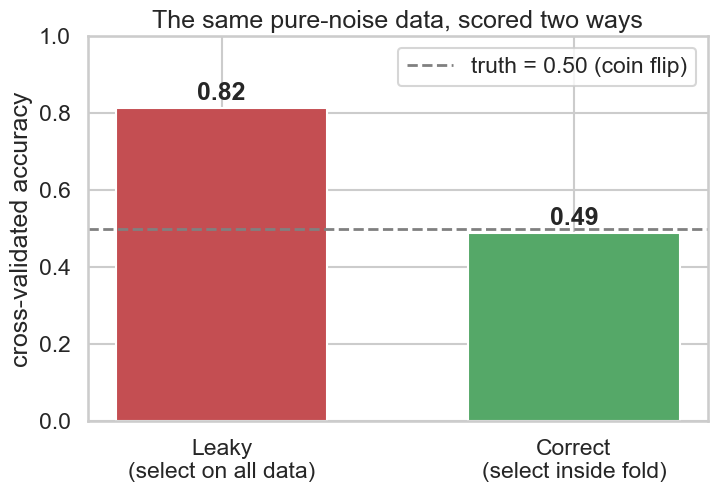

LEAKY   accuracy: 0.815  <- 'skill' invented from random numbers
CORRECT accuracy: 0.490  <- the truth: a coin flip


In [5]:
from sklearn.feature_selection import SelectKBest, f_classif
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import cross_val_score, StratifiedKFold

rng = np.random.RandomState(1)
X_noise = rng.randn(200, 10_000)          # pure noise features
y_noise = rng.randint(0, 2, size=200)     # target unrelated to anything
cv = StratifiedKFold(5, shuffle=True, random_state=0)

# WRONG: select the 20 "best" features using the FULL target, THEN cross-validate.
X_leaky = SelectKBest(f_classif, k=20).fit(X_noise, y_noise).transform(X_noise)
leaky = cross_val_score(LogisticRegression(max_iter=1000), X_leaky, y_noise,
                        cv=cv, scoring="accuracy")

# RIGHT: put selection INSIDE a Pipeline so it is re-fit on each fold's training rows only.
correct_pipe = Pipeline([("select", SelectKBest(f_classif, k=20)),
                         ("clf", LogisticRegression(max_iter=1000))])
correct = cross_val_score(correct_pipe, X_noise, y_noise, cv=cv, scoring="accuracy")

fig, ax = plt.subplots(figsize=(8, 5))
bars = ax.bar(["Leaky\n(select on all data)", "Correct\n(select inside fold)"],
              [leaky.mean(), correct.mean()],
              color=["#C44E52", "#55A868"], edgecolor="white", width=0.6)
ax.axhline(0.5, ls="--", color="gray", lw=2, label="truth = 0.50 (coin flip)")
ax.set(ylim=(0, 1), ylabel="cross-validated accuracy",
       title="The same pure-noise data, scored two ways")
for b, v in zip(bars, [leaky.mean(), correct.mean()]):
    ax.text(b.get_x()+b.get_width()/2, v+0.02, f"{v:.2f}", ha="center", fontweight="bold")
ax.legend()
plt.show()

print(f"LEAKY   accuracy: {leaky.mean():.3f}  <- 'skill' invented from random numbers")
print(f"CORRECT accuracy: {correct.mean():.3f}  <- the truth: a coin flip")

### How to read this chart

- The data has **no signal at all** — the honest score is ~0.50, and the correct green bar
  confirms it.
- The red bar clears **0.80**. That "accuracy" is 100% an artifact of choosing features while
  peeking at the test labels. On real projects this is exactly how people report a 0.95 AUC
  that collapses in production.
- The fix is mechanical and total: **every data-dependent step (encode, scale, impute, select,
  resample) must live inside a `Pipeline`, so cross-validation re-fits it on each fold's
  training rows only.** The test fold must be untouched until prediction time.

> **The golden rule of validation:** *the test fold may not influence a single number used to
> build the model.* If it does, your score is fiction.

## Section 4 — Choosing K (the number of folds)

K-fold CV splits the data into **K** equal parts, trains on K−1 and tests on the held-out
one, rotates K times, and averages. So what should K be?

- **Small K (e.g. 2–3):** each training set is smaller → the model is a bit *worse* than your
  final full-data model, so scores are **pessimistically biased**. But folds are big and the
  estimate is **stable** and **cheap**.
- **Large K (e.g. 20, or LOOCV):** training sets are nearly the full data → **low bias**, but
  the K scores are highly correlated and each test fold is tiny → **high variance** of the
  estimate, and **K times the compute**.

Let's watch the trade-off directly.

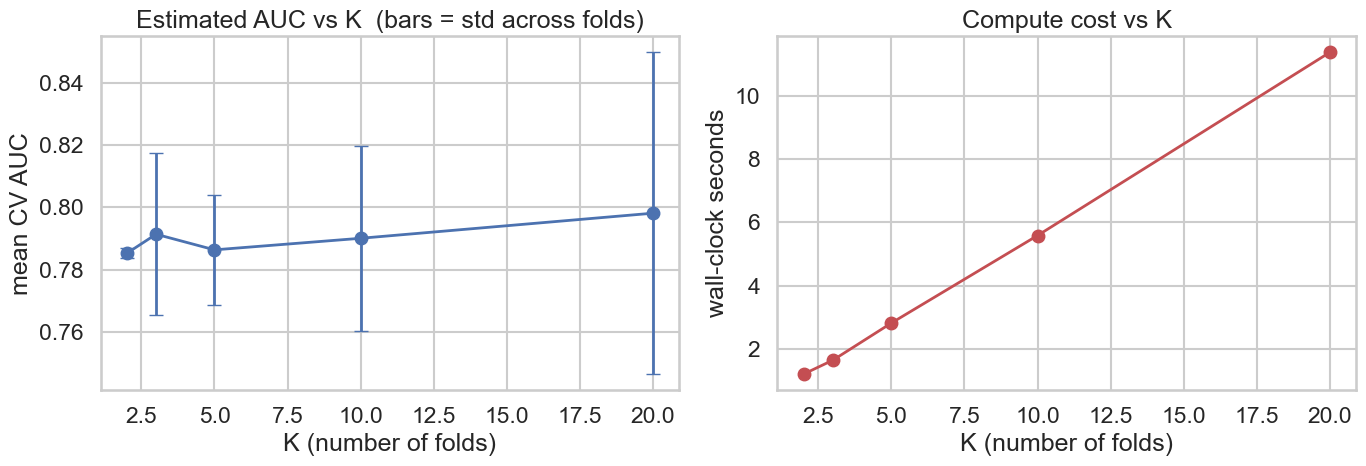

K= 2   AUC 0.785   std 0.002   time 1.2s
K= 3   AUC 0.791   std 0.026   time 1.6s
K= 5   AUC 0.786   std 0.018   time 2.8s
K=10   AUC 0.790   std 0.030   time 5.6s
K=20   AUC 0.798   std 0.052   time 11.4s


In [6]:
import time
Ks = [2, 3, 5, 10, 20]
means, stds, times = [], [], []
for k in Ks:
    t0 = time.time()
    s = cross_val_score(make_pipeline(), X, y,
                        cv=StratifiedKFold(k, shuffle=True, random_state=RANDOM_STATE),
                        scoring="roc_auc")
    means.append(s.mean()); stds.append(s.std()); times.append(time.time() - t0)

fig, axes = plt.subplots(1, 2, figsize=(14, 5))
axes[0].errorbar(Ks, means, yerr=stds, fmt="o-", color="#4C72B0", capsize=5, lw=2)
axes[0].set(title="Estimated AUC vs K  (bars = std across folds)",
            xlabel="K (number of folds)", ylabel="mean CV AUC")
axes[1].plot(Ks, times, "o-", color="#C44E52", lw=2)
axes[1].set(title="Compute cost vs K", xlabel="K (number of folds)", ylabel="wall-clock seconds")
plt.tight_layout(); plt.show()

for k, m, sd, tm in zip(Ks, means, stds, times):
    print(f"K={k:2d}   AUC {m:.3f}   std {sd:.3f}   time {tm:.1f}s")

### How to read these charts

- **Left:** the mean estimate is fairly flat, but the **error bars (fold-to-fold std) widen as
  K grows** — bigger K means tinier, noisier test folds, so the *spread* of the estimate grows
  even though its *bias* shrinks.
- **Right:** cost rises roughly linearly with K — K=20 trains the model 20 times.
- **The practical answer:** **K = 5 or 10** is the near-universal default. It keeps bias low,
  variance and cost reasonable, and is what you should reach for unless you have a specific
  reason not to. LOOCV (K = n) is covered in Notebook 02.

## Key takeaways

1. **A score on training data is not a result.** Always evaluate on rows the model never saw.
2. **One split is a lottery.** Cross-validation rotates the test set through all rows and
   averages, turning a noisy point estimate into a stable one *plus* a stability estimate.
3. **Leakage manufactures fake skill** — we pulled 0.82 accuracy out of pure noise. Put every
   data-dependent step inside a `Pipeline` so CV re-fits it per fold. The test fold stays
   untouched until prediction.
4. **K = 5 or 10** is the default: a sensible point on the bias / variance / cost curve.

### Next → **02 — The K-Fold Family**
Now that the ground rules are set, we tour the actual splitters: plain `KFold`,
`StratifiedKFold`, `RepeatedStratifiedKFold`, `ShuffleSplit`, `LeaveOneOut`, out-of-fold
predictions with `cross_val_predict`, and cross-validation for a **regression** target.